# Análisis de Supervivencia en el Titanic

Este notebook explora los factores que influyeron en la supervivencia de los pasajeros del Titanic usando Pandas y Matplotlib.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [5]:
df = pd.read_csv('/Users/carlosmendoza/Desktop/data-science-portfolio/titanic_analysis/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
## Exploracion Inicial

In [7]:
print("=== Primeras 5 filas ===")
print(df.head())
print("\n=== Informacion del DataFrame ===")
print(df.info())
print("\n=== Estadisticas descriptivas ===")
print(df.describe())

=== Primeras 5 filas ===
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

In [8]:
## Valores Nulos

In [9]:
print("\n=== Nulos por columna ===")
print(df.isnull().sum())


=== Nulos por columna ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [10]:
## Tratar Nulos:
## - Edad: rellenar con la mediana

In [11]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [12]:
## - Embarcado: rellenar con la moda

In [13]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [14]:
## - Cabina eliminar columna por demasiados nulos

In [16]:
df.drop('Cabin', axis=1, inplace=True)

In [17]:
## Verificar que ya no hay nulos

In [18]:
print("\n=== Nulos despues de limpieza ===")
print(df.isnull().sum())


=== Nulos despues de limpieza ===
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [19]:
## Crear columnas nuevas

In [20]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [21]:
## Visualizaciones
## Supervivencia pore sexo

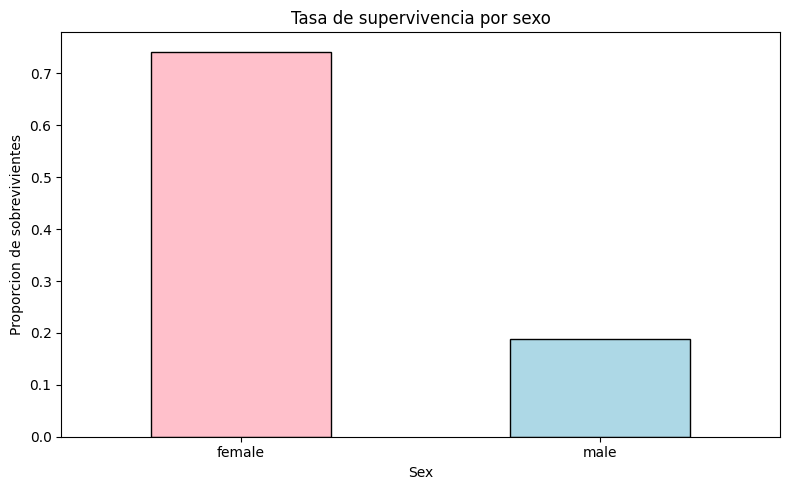

In [23]:
plt.figure(figsize=(8,5))
df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['pink', 'lightblue'], edgecolor='black')
plt.title('Tasa de supervivencia por sexo')
plt.ylabel('Proporcion de sobrevivientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('supervivencia_por_sexo.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
## Supervivencia por clase

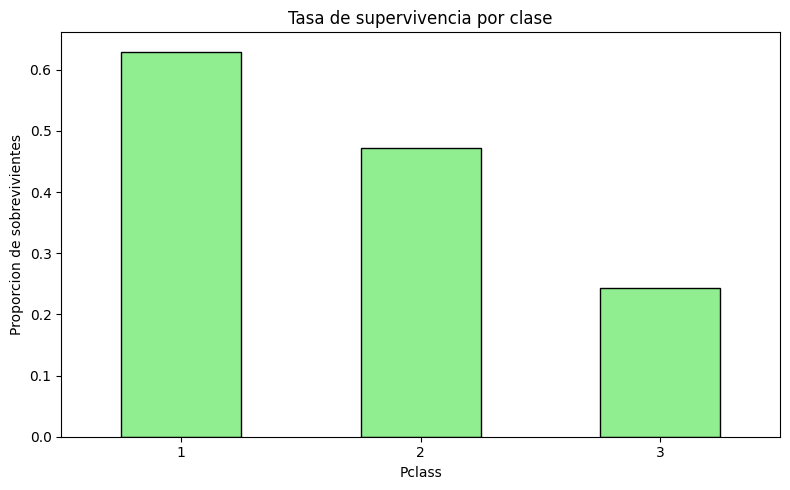

In [25]:
plt.figure(figsize=(8,5))
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Tasa de supervivencia por clase')
plt.ylabel('Proporcion de sobrevivientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('supervivencia_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
## Distribucion de edad por supervivencia

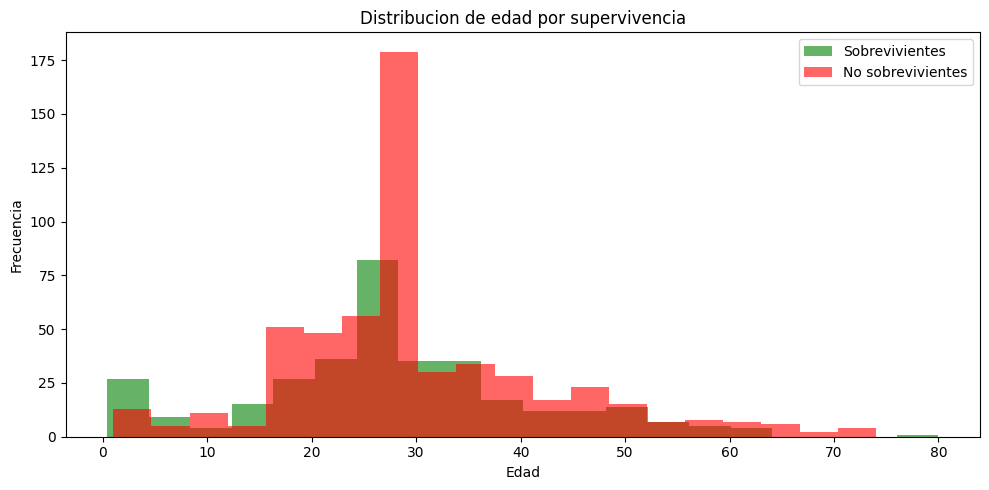

In [27]:
plt.figure(figsize=(10,5))
sobrevivientes = df[df['Survived']==1]['Age']
no_sobrevivientes = df[df['Survived']==0]['Age']
plt.hist(sobrevivientes, bins=20, alpha=0.6, label='Sobrevivientes', color='green')
plt.hist(no_sobrevivientes, bins=20, alpha=0.6, label='No sobrevivientes', color='red')
plt.title('Distribucion de edad por supervivencia')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.savefig('distribucion_edad_supervivencia.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
## Agrupacion por sexo y clase

In [29]:
print("\n=== Tasa de supervivencia por sexo y clase ===")
print(df.groupby(['Sex', 'Pclass'])['Survived'].mean())


=== Tasa de supervivencia por sexo y clase ===
Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64
